# 02 — Stylised facts of `TSM` returns

**Workstream B** of the group project plan. The brief asks for one share, examined at daily, weekly and
monthly frequency, against six stylised facts — and is explicit that we **assess** each one rather than
assume it holds. This notebook produces every table and figure report section 3 (*Stylised facts*) is
anchored on, and ends with the verdict table that section opens with.

| Task | Output |
| --- | --- |
| B1, B4 | **Table 2.1 — Descriptive statistics and normality tests** |
| B2 | **Figure 2.1 — Log returns over time** |
| B3 | **Figure 2.2 — Return distribution** (daily; weekly and monthly in Figure A2.1) |
| B5 | **Table 2.2 — Tail quantiles** (plus Table A2.1, exceedance counts) |
| B6, B7 | **Figure 2.3a–c — ACF of raw, absolute and squared returns** (weekly/monthly in Figures A2.2–A2.3) |
| B6, B8 | **Table 2.3 — Serial dependence and ARCH tests** |
| B9, B10 | **Table 2.4 — Volatility models** (daily; weekly and monthly in Table A2.2) |
| B11 | **Figure 2.4 — News impact curve** |
| B12 | **Figure 2.5 — Standardised residuals** + residual rows in Table 2.1 |
| B13 | **Table 2.5 — Stylised facts summary** |

Shared code: `src/stylised.py` (statistics, tests, models, verdict rules) and `src/viz.py` (figures).
All returns are **log returns in percent**, from the panel built in notebook 01.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import config as cfg
from src import data, fmt, stylised as sf, viz

viz.use_house_style()
np.random.seed(cfg.SEED)  # nothing here is random, but the seed is fixed everywhere

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

TICKER = cfg.STYLISED_FACTS_TICKER

---

## Data

The panel is rebuilt exactly as in notebook 01 — nothing is read from disk. The stylised-facts sample is
the **full 15-year panel** for `TSM`, which has data throughout, so no six-asset truncation applies here.

Weekly and monthly series keep **complete periods only**. The first week and month always miss the move
into the panel's first session, and an extraction mid-month leaves a stub of a few sessions at the end;
both would be returns over a shorter horizon than their label claims, so they are dropped.

In [2]:
close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
returns = data.build_returns(panel)
r = sf.share_returns(returns, panel.calendar, TICKER)

print(f"Extraction date : {extraction_date.isoformat()}")
print(f"Share           : {TICKER} — {cfg.UNIVERSE[TICKER]['name']} ({cfg.UNIVERSE[TICKER]['instrument']})")
for frequency, series in r.items():
    print(f"{frequency:<8}: n = {len(series):>5,}   {series.index[0].date()} to {series.index[-1].date()}")

Extraction date : 2026-10-05
Share           : TSM — Taiwan Semiconductor Manufacturing (ADR)
daily   : n = 3,771   2011-10-04 to 2026-10-02
weekly  : n =   782   2011-10-14 to 2026-10-02
monthly : n =   179   2011-11-30 to 2026-09-30


---

## B1, B4 — Table 2.1, descriptive statistics and normality tests

Three normality tests, because they look at different things. **Jarque–Bera** tests skewness and
kurtosis jointly; **Shapiro–Wilk** is the most powerful omnibus test in moderate samples; **Anderson–
Darling** weights the tails most heavily. The D'Agostino skew and kurtosis tests separate the two
moments, which the verdicts need. Kurtosis is **excess** kurtosis throughout: 0 for a normal.

The residual rows (B12) are added below, once the volatility model is fitted.

In [3]:
descriptive = sf.descriptive_table(r)

TABLE_2_1_RULES = {
    "n": fmt.count,
    **{c: (lambda v: fmt.percent(v, 2)) for c in ["Mean %", "SD %", "Min %", "Max %"]},
    **{c: (lambda v: fmt.number(v, 2)) for c in ["Skew", "Excess kurtosis", "JB stat", "AD stat"]},
    "SW stat": lambda v: fmt.number(v, 3),
    **{c: fmt.pvalue for c in ["Skew p", "Kurtosis p", "JB p", "SW p", "AD p"]},
}

def period(frequency):
    s = r[frequency]
    return f"{s.index[0]:%Y-%m} to {s.index[-1]:%Y-%m}"

print(f"Table 2.1 - Descriptive statistics, {TICKER} log returns. {period('daily')}; "
      f"n = {len(r['daily']):,} / {len(r['weekly']):,} / {len(r['monthly']):,} (daily / weekly / monthly). "
      "Per-period, not annualised. Kurtosis is excess kurtosis.")
display(fmt.style(descriptive, TABLE_2_1_RULES))

Table 2.1 - Descriptive statistics, TSM log returns. 2011-10 to 2026-10; n = 3,771 / 782 / 179 (daily / weekly / monthly). Per-period, not annualised. Kurtosis is excess kurtosis.


,n,Mean %,SD %,Min %,Max %,Skew,Skew p,Excess kurtosis,Kurtosis p,JB stat,JB p,SW stat,SW p,AD stat,AD p
Series,,,,,,,,,,,,,,,
daily,"3,771",0.11,2.00,-15.12,11.91,0.01,0.788,4.14,<0.001,2690.14,<0.001,0.961,<0.001,26.03,<0.001
weekly,782,0.52,3.95,-15.01,16.69,-0.01,0.878,1.13,<0.001,41.66,<0.001,0.989,<0.001,2.48,<0.001
monthly,179,2.22,8.04,-18.97,32.90,0.23,0.197,1.27,0.008,13.60,0.001,0.980,0.012,0.72,0.061


Two things are visible before any test. **Fat tails are strongest at daily frequency and fade as
returns aggregate** — excess kurtosis falls from about 4 to about 1 — which is what the central limit
theorem predicts for sums of weakly dependent shocks. And **the skewness is close to zero at every
frequency**, positive at monthly. The negative-skew fact is not visible in this share.

---

## B2 — Figure 2.1, log returns over time

Each panel has its own y-scale: a monthly move is the sum of about 21 daily ones, so a shared scale would
flatten the daily series and hide the clustering this figure is for.

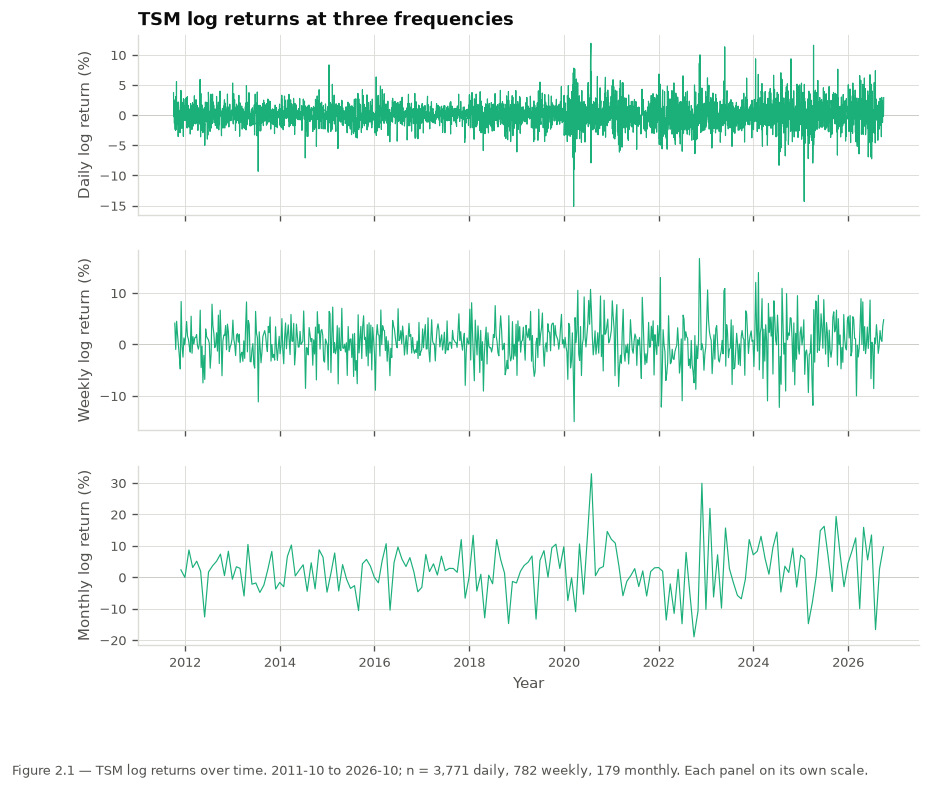

In [4]:
fig, axes = viz.return_panels(r, TICKER)
axes[0].set_title(f"{TICKER} log returns at three frequencies")
viz.caption(
    axes[-1],
    f"Figure 2.1 — {TICKER} log returns over time. {period('daily')}; "
    f"n = {len(r['daily']):,} daily, {len(r['weekly']):,} weekly, {len(r['monthly']):,} monthly. "
    "Each panel on its own scale.",
)
plt.show()

The daily panel shows the clustering directly: calm stretches (2013–2014, 2017) alternate with bursts
(late 2018, March 2020, 2022, the 2024–25 AI-driven swings), and large moves sit next to large moves.
The monthly panel is much harder to read the same way, which anticipates the weaker monthly evidence in
Table 2.3.

---

## B3 — Figure 2.2, return distribution

The histogram sits against a normal with the **same mean and standard deviation**, so any difference is
shape alone. On the Q–Q plot, points above the line on the right and below it on the left are fat tails.
The main report shows daily; weekly and monthly go to the appendix as Figure A2.1.

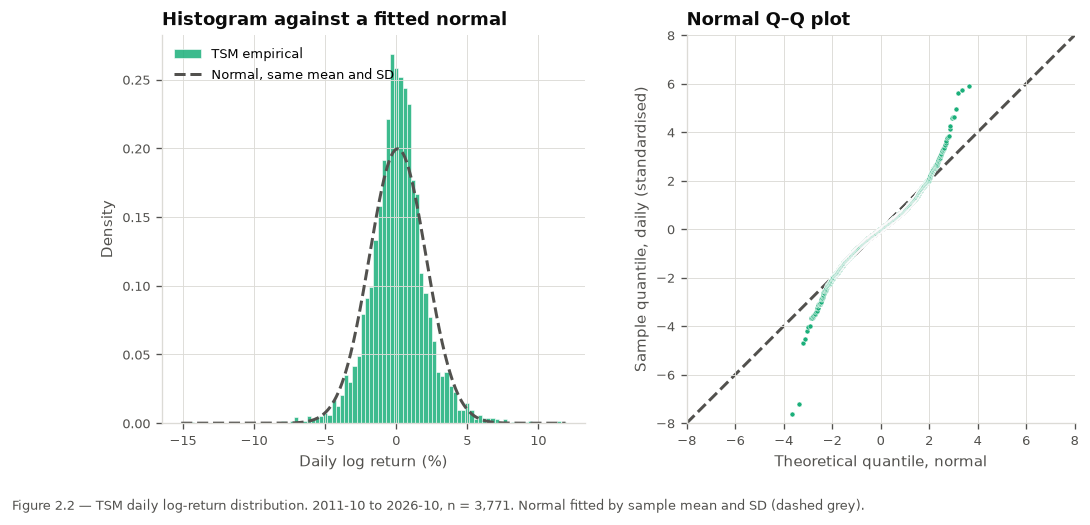

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
viz.distribution_pair(r["daily"], TICKER, axes, label="Daily")
axes[0].set_title("Histogram against a fitted normal")
axes[1].set_title("Normal Q–Q plot")
viz.caption(
    axes[0],
    f"Figure 2.2 — {TICKER} daily log-return distribution. {period('daily')}, n = {len(r['daily']):,}. "
    "Normal fitted by sample mean and SD (dashed grey).",
)
plt.show()

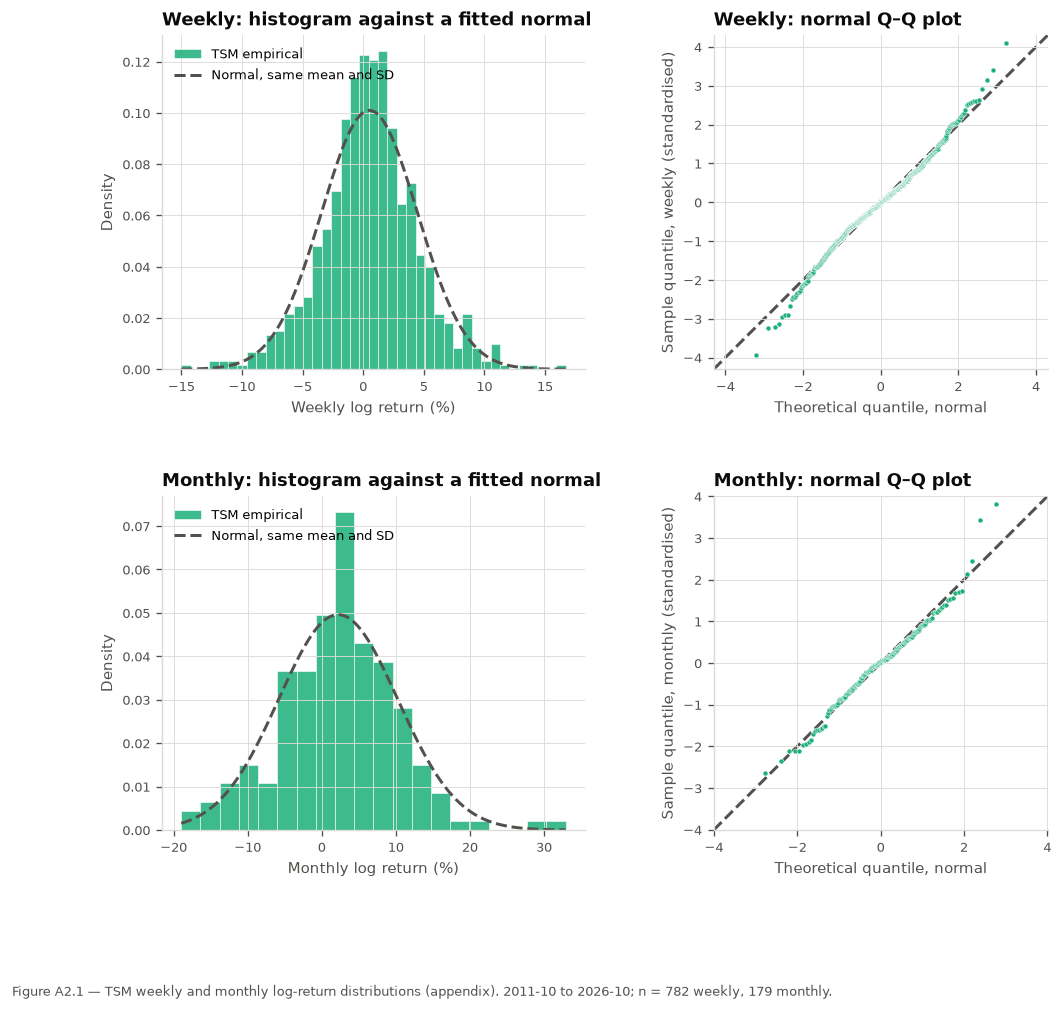

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 8.6))
fig.subplots_adjust(hspace=0.38)
for row, frequency in zip(axes, ["weekly", "monthly"]):
    viz.distribution_pair(r[frequency], TICKER, row, label=frequency.capitalize())
    row[0].set_title(f"{frequency.capitalize()}: histogram against a fitted normal")
    row[1].set_title(f"{frequency.capitalize()}: normal Q–Q plot")
viz.caption(
    axes[1, 0],
    f"Figure A2.1 — {TICKER} weekly and monthly log-return distributions (appendix). {period('weekly')}; "
    f"n = {len(r['weekly']):,} weekly, {len(r['monthly']):,} monthly.",
)
plt.show()

---

## B5 — Table 2.2, tail quantiles

Empirical quantiles against those of the moment-matched normal. The ratio is measured from the mean, so
it reads the same way in both tails: above 1 means the empirical tail is further out than the normal
puts it.

In [7]:
tails = sf.tail_table(r)
print(f"Table 2.2 - Tail quantiles, {TICKER} log returns, empirical against a normal with the sample "
      f"mean and SD. {period('daily')}. Ratio measured from the mean.")
display(fmt.style(tails.reset_index(), {
    "Quantile %": lambda v: fmt.number(v, 0),
    "Empirical %": lambda v: fmt.percent(v, 2),
    "Normal-implied %": lambda v: fmt.percent(v, 2),
    "Ratio": lambda v: fmt.number(v, 2),
}).set_index(["Frequency", "Quantile %"]))

Table 2.2 - Tail quantiles, TSM log returns, empirical against a normal with the sample mean and SD. 2011-10 to 2026-10. Ratio measured from the mean.


Empirical % Normal-implied % Ratio
Frequency Quantile %                                   
daily     1                -5.05            -4.54  1.11
          5                -3.01            -3.18  0.95
          95                3.32             3.40  0.98
          99                5.44             4.76  1.15
weekly    1                -9.48            -8.67  1.09
          5                -6.03            -5.98  1.01
          95                6.84             7.02  0.97
          99               10.62             9.71  1.10
monthly   1               -15.22           -16.49  0.93
          5               -11.62           -11.01  1.05
          95               14.38            15.45  0.92
          99               23.66            20.93  1.15

In [8]:
exceed = sf.exceedance_table(r)
print("Table A2.1 - Moves beyond k standard deviations, observed against the normal-expected count "
      f"(appendix). {period('daily')}.")
display(fmt.style(exceed.reset_index(), {
    "Observed": fmt.count,
    "Normal-expected": lambda v: fmt.number(v, 3),
    # No more precision than the estimate supports: a ratio in the thousands is a count.
    "Ratio": lambda v: fmt.number(v, 1) if v < 100 else fmt.count(v),
}).set_index(["Frequency", "Beyond ±kσ"]))

Table A2.1 - Moves beyond k standard deviations, observed against the normal-expected count (appendix). 2011-10 to 2026-10.


Observed Normal-expected  Ratio
Frequency Beyond ±kσ                                
daily     3                53          10.181    5.2
          4                16           0.239   67.0
          5                 5           0.002  2,313
weekly    3                 7           2.111    3.3
          4                 1           0.050   20.2
          5                 0           0.000    0.0
monthly   3                 2           0.483    4.1
          4                 0           0.011    0.0
          5                 0           0.000    0.0

The quantile table shows the characteristic fat-tail signature: at daily frequency the **5% and 95%
quantiles sit *inside* the normal's** (ratio below 1 — the distribution is more peaked) while the **1%
and 99% sit outside** it. The exceedance counts make the same point more starkly: daily moves beyond
4σ and 5σ occur many times more often than a normal allows. At monthly frequency the ratios are close
to 1, and the extreme-move counts are too small to say much.

---

## B6, B7, B8 — serial dependence and volatility clustering

The same tool answers two different questions. The ACF of **raw** returns tests whether the *direction*
of returns is predictable (fact 1). The ACF of **absolute** and **squared** returns tests whether the
*size* of returns is (fact 4). Drawing them side by side on one scale is the argument.

**One methodological point decides fact 1.** The usual ±1.96/√n band and the Ljung–Box test both assume
iid returns. When volatility clusters — which the right-hand panels show it does — they **over-reject**:
a few huge-variance days make sample autocorrelations noisier than the band allows. So we also report a
**heteroskedasticity-robust** band and portmanteau test (each lag's variance estimated from the
cross-products r_t·r_{t−k}), and the fact-1 verdict is judged on the robust version.

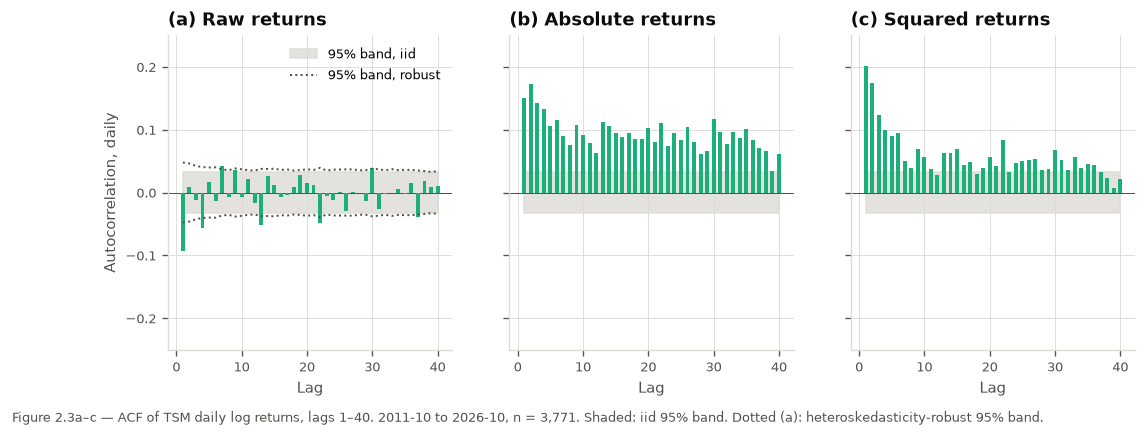

In [9]:
acfs = {frequency: sf.acf_frame(series) for frequency, series in r.items()}

fig, axes = viz.acf_panels(acfs["daily"], TICKER, label="daily")
for ax, letter in zip(axes, "abc"):
    ax.set_title(f"({letter}) {ax.get_title(loc='left')}", loc="left")
viz.caption(
    axes[0],
    f"Figure 2.3a–c — ACF of {TICKER} daily log returns, lags 1–{sf.ACF_LAGS}. {period('daily')}, "
    f"n = {len(r['daily']):,}. Shaded: iid 95% band. Dotted (a): heteroskedasticity-robust 95% band.",
)
plt.show()

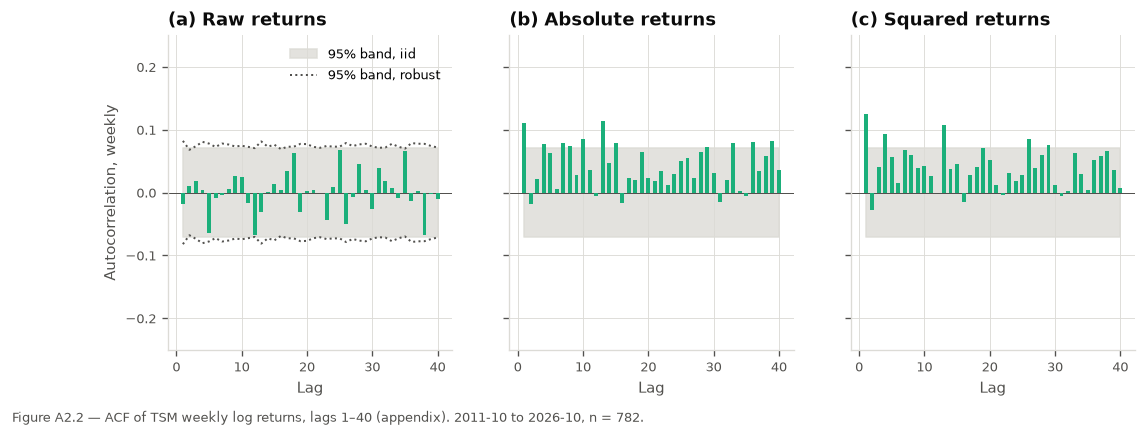

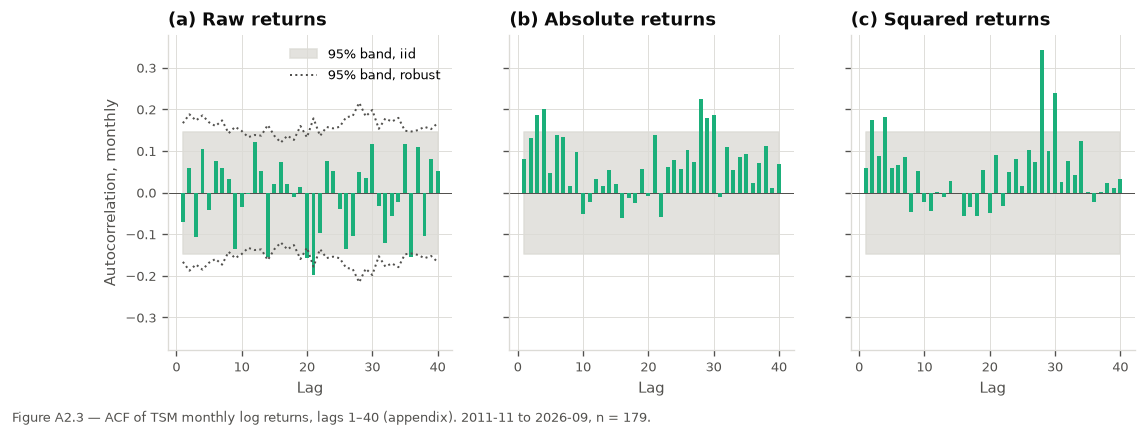

In [10]:
for number, frequency in (("A2.2", "weekly"), ("A2.3", "monthly")):
    fig, axes = viz.acf_panels(acfs[frequency], TICKER, label=frequency)
    for ax, letter in zip(axes, "abc"):
        ax.set_title(f"({letter}) {ax.get_title(loc='left')}", loc="left")
    viz.caption(
        axes[0],
        f"Figure {number} — ACF of {TICKER} {frequency} log returns, lags 1–{sf.ACF_LAGS} (appendix). "
        f"{period(frequency)}, n = {len(r[frequency]):,}.",
    )
    plt.show()

In [11]:
dependence = sf.dependence_table(r)
print(f"Table 2.3 - Serial dependence and ARCH tests, {TICKER} log returns. Ljung-Box Q and the robust "
      f"portmanteau Q* are chi-squared with k degrees of freedom; ARCH-LM is the LM statistic on k lags "
      f"of squared demeaned returns. {period('daily')}.")
display(fmt.style(dependence, {
    **{f"Q({k})": (lambda v: fmt.number(v, 2)) for k in sf.LB_LAGS},
    **{f"p({k})": fmt.pvalue for k in sf.LB_LAGS},
}))

Table 2.3 - Serial dependence and ARCH tests, TSM log returns. Ljung-Box Q and the robust portmanteau Q* are chi-squared with k degrees of freedom; ARCH-LM is the LM statistic on k lags of squared demeaned returns. 2011-10 to 2026-10.


Q(5)    p(5)   Q(10)   p(10)   Q(20)   p(20)
Frequency Test                                                                   
daily     Ljung–Box, raw            46.36  <0.001   59.24  <0.001   80.21  <0.001
          Ljung–Box, absolute      382.90  <0.001  560.50  <0.001  882.05  <0.001
          Ljung–Box, squared       392.97  <0.001  472.39  <0.001  566.47  <0.001
          Robust portmanteau, raw   23.08  <0.001   32.44  <0.001   48.13  <0.001
          ARCH-LM                  256.71  <0.001  273.24  <0.001  290.88  <0.001
weekly    Ljung–Box, raw             3.87   0.568    5.00   0.891   14.78   0.789
          Ljung–Box, absolute       17.88   0.003   33.51  <0.001   56.22  <0.001
          Ljung–Box, squared        23.72  <0.001   32.95  <0.001   53.72  <0.001
          Robust portmanteau, raw    3.15   0.677    4.16   0.940   13.16   0.870
          ARCH-LM                   21.99  <0.001   26.91   0.003   40.24   0.005
monthly   Ljung–Box, raw             5.93   0.313   11.57   0.315   25.88   0.170
          Ljung–Box, absolute       18.61   0.002   27.78   0.002   30.36   0.064
          Ljung–Box, squared        14.27   0.014   17.42   0.066   20.58   0.422
          Robust portmanteau, raw    4.02   0.546    8.78   0.553   24.18   0.235
          ARCH-LM                   12.04   0.034   13.76   0.184   18.82   0.533

In [12]:
for frequency in cfg.FREQUENCY_ORDER:
    a = acfs[frequency]
    print(f"{frequency:<8} lag-1 ρ = {a.loc[1, 'raw']:+.3f}   iid band ±{a.loc[1, 'band']:.3f}   "
          f"robust band ±{a.loc[1, 'robust_band']:.3f}   "
          f"lag-1 ρ of |r| = {a.loc[1, 'absolute']:.3f}")

daily    lag-1 ρ = -0.093   iid band ±0.032   robust band ±0.048   lag-1 ρ of |r| = 0.150
weekly   lag-1 ρ = -0.018   iid band ±0.070   robust band ±0.082   lag-1 ρ of |r| = 0.110
monthly  lag-1 ρ = -0.070   iid band ±0.146   robust band ±0.167   lag-1 ρ of |r| = 0.081


**Fact 1 is a frequency story.** At weekly and monthly frequency every test, plain and robust, fails to
reject: no serial correlation, as the fact predicts. At **daily** frequency there is a single
**negative lag-1 autocorrelation of about −0.09** that survives the robust test. It is statistically real
but economically small — it explains under 1% of next-day variance, well inside the round-trip trading
cost of exploiting it. The likely source is the ADR structure: `TSM` trades in New York while the
underlying share trades in Taipei during the US night, so part of each day's ADR move is a lagged
response to, and partial reversal of, the previous Taipei session. Hence *Partial*, not *Supported*.

**Fact 4 is equally clear in the other direction.** The absolute and squared ACFs are positive and
decay slowly out to lag 40 at daily frequency — the clustering signature. Weekly is still decisive;
monthly is borderline, with clustering detected at short lags only.

---

## B9, B10 — Table 2.4, volatility models

Four GARCH-family models, constant mean, on percent log returns:

| Model | What it adds |
| --- | --- |
| GARCH(1,1), normal | The baseline: σ²_t = ω + α ε²_{t−1} + β σ²_{t−1} |
| GARCH(1,1), Student-t | Same variance equation; fat-tailed errors with ν degrees of freedom |
| GJR-GARCH(1,1), t | Adds γ ε²_{t−1}·1[ε_{t−1} < 0]: **γ > 0 is the leverage effect** |
| EGARCH(1,1), t | Log-variance with a signed term γ z_{t−1}: **γ < 0 is the leverage effect** |

GARCH-N against GARCH-t isolates the error assumption; GJR and EGARCH are two different
parameterisations of the same asymmetry question, so a leverage effect that is real should show up in
both. Persistence is α + β (+ γ/2 for GJR), or β for EGARCH.

In [13]:
fits = {frequency: sf.fit_models(series, frequency) for frequency, series in r.items()}
model_tables = {frequency: sf.model_table(f) for frequency, f in fits.items()}

MODEL_RULES = {}
for model in sf.MODELS:
    MODEL_RULES[(model, "Estimate")] = lambda v: fmt.number(v, 4)
    MODEL_RULES[(model, "SE")] = lambda v: fmt.number(v, 4)
    MODEL_RULES[(model, "p")] = fmt.pvalue

def show_model_table(frequency, number):
    t = model_tables[frequency].copy()
    styled = t.copy().astype(object)
    for col, rule in MODEL_RULES.items():
        styled[col] = t[col].map(rule)
    # Fit statistics carry no standard error; log-likelihood and ICs need no 4 dp.
    for row in ["Log-likelihood", "AIC", "BIC"]:
        for model in sf.MODELS:
            styled.loc[row, (model, "Estimate")] = fmt.number(t.loc[row, (model, "Estimate")], 1)
    for model in sf.MODELS:
        styled.loc["Converged", (model, "Estimate")] = "Yes" if t.loc["Converged", (model, "Estimate")] else "No"
    print(f"Table {number} - Volatility models, {TICKER} {frequency} log returns (%), constant mean. "
          f"{period(frequency)}, n = {len(r[frequency]):,}. Quasi-ML robust standard errors.")
    display(styled.fillna(fmt.NA))

show_model_table("daily", "2.4")

Table 2.4 - Volatility models, TSM daily log returns (%), constant mean. 2011-10 to 2026-10, n = 3,771. Quasi-ML robust standard errors.


GARCH-N                  GARCH-t                    GJR-t                 EGARCH-t                
               Estimate      SE       p Estimate      SE       p Estimate      SE       p Estimate      SE       p
Parameter                                                                                                         
μ                0.1142  0.0288  <0.001   0.1136  0.0252  <0.001   0.1099  0.0258  <0.001   0.1118  0.0258  <0.001
ω                0.0423  0.0237   0.074   0.0272  0.0132   0.040   0.0277  0.0138   0.045   0.0187  0.0059   0.001
α                0.0447  0.0127  <0.001   0.0439  0.0091  <0.001   0.0395  0.0089  <0.001   0.1107  0.0179  <0.001
γ                     —       —       —        —       —       —   0.0104  0.0114   0.360  -0.0162  0.0105   0.124
β                0.9451  0.0173  <0.001   0.9507  0.0108  <0.001   0.9499  0.0113  <0.001   0.9899  0.0039  <0.001
ν                     —       —       —   5.3986  0.4595  <0.001   5.4060  0.4616  <0.001   5.4207  0.4658  <0.001
Persistence      0.9897       —       —   0.9946       —       —   0.9946       —       —   0.9899       —       —
Log-likelihood  -7709.6       —       —  -7577.1       —       —  -7576.6       —       —  -7573.1       —       —
AIC             15427.1       —       —  15164.2       —       —  15165.1       —       —  15158.3       —       —
BIC             15452.1       —       —  15195.3       —       —  15202.6       —       —  15195.7       —       —
Converged           Yes       —       —      Yes       —       —      Yes       —       —      Yes       —       —

In [14]:
show_model_table("weekly", "A2.2a")
show_model_table("monthly", "A2.2b")

Table A2.2a - Volatility models, TSM weekly log returns (%), constant mean. 2011-10 to 2026-10, n = 782. Quasi-ML robust standard errors.


GARCH-N                  GARCH-t                    GJR-t                 EGARCH-t                
               Estimate      SE       p Estimate      SE       p Estimate      SE       p Estimate      SE       p
Parameter                                                                                                         
μ                0.4952  0.1363  <0.001   0.5221  0.1265  <0.001   0.5096  0.1263  <0.001   0.5002  0.1264  <0.001
ω                0.0947  0.1464   0.518   0.1097  0.1199   0.360   0.1094  0.1326   0.409   0.0199  0.0395   0.614
α                0.0202  0.0195   0.302   0.0281  0.0154   0.068   0.0225  0.0125   0.072   0.0504  0.0639   0.430
γ                     —       —       —        —       —       —   0.0147  0.0237   0.535  -0.0136  0.0186   0.466
β                0.9744  0.0280  <0.001   0.9661  0.0195  <0.001   0.9644  0.0212  <0.001   0.9937  0.0138  <0.001
ν                     —       —       —   7.1950  1.7416  <0.001   7.1159  1.7103  <0.001   6.9495  1.7195  <0.001
Persistence      0.9946       —       —   0.9942       —       —   0.9943       —       —   0.9937       —       —
Log-likelihood  -2164.6       —       —  -2154.2       —       —  -2153.9       —       —  -2156.6       —       —
AIC              4337.3       —       —   4318.3       —       —   4319.8       —       —   4325.1       —       —
BIC              4355.9       —       —   4341.6       —       —   4347.8       —       —   4353.1       —       —
Converged           Yes       —       —      Yes       —       —      Yes       —       —      Yes       —       —

Table A2.2b - Volatility models, TSM monthly log returns (%), constant mean. 2011-11 to 2026-09, n = 179. Quasi-ML robust standard errors.


GARCH-N                  GARCH-t                    GJR-t                 EGARCH-t                
               Estimate      SE       p Estimate      SE       p Estimate      SE       p Estimate      SE       p
Parameter                                                                                                         
μ                2.0356  0.5309  <0.001   2.0970  0.5303  <0.001   2.0321  0.5230  <0.001   2.1571  0.0063  <0.001
ω                0.4229  0.6253   0.499   0.4341  0.6087   0.476   0.4007  1.1232   0.721  -0.0054  0.0000  <0.001
α                0.0000  0.0090   1.000   0.0000  0.0098   1.000   0.0000  0.0359   1.000  -0.1323  0.0004  <0.001
γ                     —       —       —        —       —       —   0.0391  0.0581   0.501  -0.0086  0.0006  <0.001
β                1.0000  0.0176  <0.001   1.0000  0.0166  <0.001   0.9805  0.0382  <0.001   1.0000  0.0000  <0.001
ν                     —       —       —   9.3737  6.7753   0.167  10.8585  7.8742   0.168  11.5957  0.4915  <0.001
Persistence      1.0000       —       —   1.0000       —       —   1.0000       —       —   1.0000       —       —
Log-likelihood   -616.1       —       —   -614.6       —       —   -614.3       —       —   -609.3       —       —
AIC              1240.2       —       —   1239.2       —       —   1240.6       —       —   1230.7       —       —
BIC              1252.9       —       —   1255.1       —       —   1259.7       —       —   1249.8       —       —
Converged           Yes       —       —      Yes       —       —      Yes       —       —      Yes       —       —

In [15]:
failures = pd.DataFrame(
    [
        {"Frequency": f.frequency, "Model": f.name, "Converged": f.converged,
         "Degenerate (α≈0, β≈1)": f.degenerate, "Message": f.message or fmt.NA}
        for by_model in fits.values() for f in by_model.values()
        if not f.converged or f.degenerate
    ]
)
print("Estimation problems — logged, not dropped:")
display(failures if not failures.empty else "None.")

Estimation problems — logged, not dropped:


,Frequency,Model,Converged,"Degenerate (α≈0, β≈1)",Message
0,monthly,GARCH-N,True,True,—
1,monthly,GARCH-t,True,True,—
2,monthly,GJR-t,True,True,—


**Daily.** Every model finds strong, persistent clustering: α ≈ 0.04, β ≈ 0.95, persistence ≈ 0.99.
Moving from normal to Student-t errors raises the log-likelihood by over 130 points for one extra
parameter, with **ν ≈ 5.4** — the conditional distribution is itself fat-tailed (fact 6, below).

**The leverage term is not significant.** GJR's γ is positive, the right sign, but small and
insignificant (p ≈ 0.36); EGARCH's γ is negative, again the right sign, and again insignificant
(p ≈ 0.12). We checked this is not an artefact of the specification: adding an AR(1) term to the mean,
or splitting the sample at 2019, leaves γ insignificant in every case. For this share, negative
returns do not raise next-day volatility measurably more than positive ones of the same size. That is
a known pattern rather than an anomaly — the leverage effect is strongest at **index** level, and
weaker for individual growth stocks, where large positive surprises (TSM's 2023–25 AI repricing) are as
volatility-generating as large negative ones.

**Weekly** clustering is still identified, with high persistence. **Monthly** GARCH is degenerate: the
ARCH term sits on its zero bound and β = 1, so the model is not identified — 179 observations of a
smoothed series are not enough to estimate a volatility process. Monthly verdicts that rest on the
model are qualified accordingly.

---

## B11 — Figure 2.4, news impact curve

Next-day conditional variance as a function of today's shock, with yesterday's variance held at the
unconditional level (Engle and Ng, 1993). A leverage effect makes the curve steeper on the left. The
symmetric GARCH-t curve is drawn as the grey reference.

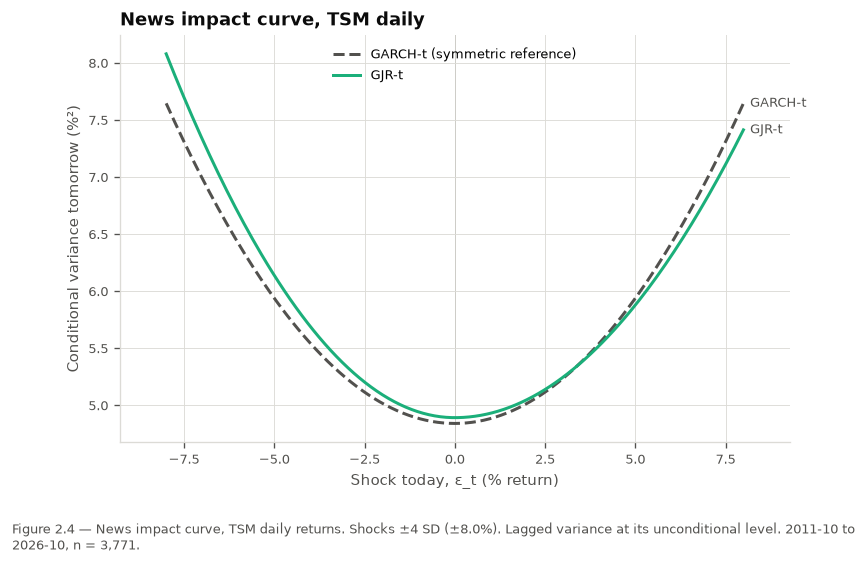

GJR-t    : next-day variance after a -4 SD shock 8.08, after +4 SD 7.41 (ratio 1.09).
EGARCH-t : next-day variance after a -4 SD shock 8.70, after +4 SD 7.85 (ratio 1.11).


In [16]:
daily_sd = r["daily"].std()
shocks = np.linspace(-4 * daily_sd, 4 * daily_sd, 201)
curves = {name: sf.news_impact(fits["daily"][name], shocks) for name in ("GARCH-t", "GJR-t", "EGARCH-t")}

fig, ax = plt.subplots(figsize=(7.2, 4.4))
# EGARCH's curve sits on a different level (log-variance), so it is quoted below, not drawn.
viz.news_impact_plot({k: curves[k] for k in ("GARCH-t", "GJR-t")}, TICKER, reference="GARCH-t", ax=ax)
ax.set_title(f"News impact curve, {TICKER} daily")
viz.caption(
    ax,
    f"Figure 2.4 — News impact curve, {TICKER} daily returns. Shocks ±4 SD (±{4 * daily_sd:.1f}%). "
    f"Lagged variance at its unconditional level. {period('daily')}, n = {len(r['daily']):,}.",
)
plt.show()

for name in ("GJR-t", "EGARCH-t"):
    left, right = curves[name].iloc[0], curves[name].iloc[-1]
    print(f"{name:<9}: next-day variance after a -4 SD shock {left:.2f}, after +4 SD {right:.2f} "
          f"(ratio {left / right:.2f}).")

The asymmetry is visible but slight. The GJR curve leans left of the symmetric reference, yet a
−4 SD shock raises next-day variance only about 9% more than a +4 SD one; EGARCH gives about 11%. The
figure is the picture of Table 2.4's insignificant γ — the right shape, not enough of it to
distinguish from noise.

---

## B12 — Figure 2.5, standardised residuals

If GARCH captured *all* the non-normality, the standardised residuals z_t = ε_t / σ_t would be normal:
the fat tails would be nothing but a mixture of normals with changing variance. Fact 6 says they are
not. We test it on the residuals of the **GJR-t** model, the richest specification, against both the
normal and the Student-t the model itself estimated.

In [17]:
residuals = {frequency: fits[frequency][sf.PREFERRED_MODEL].std_resid for frequency in cfg.FREQUENCY_ORDER}
residual_stats = sf.descriptive_table(residuals)

table_2_1 = pd.concat([descriptive, residual_stats.rename(index=lambda f: f"{f}, std. residuals")])
print(f"Table 2.1 - Descriptive statistics, {TICKER} log returns and {sf.PREFERRED_MODEL} standardised "
      f"residuals. {period('daily')}. Residual rows are unit-variance by construction; "
      "their mean and SD are not in %.")
display(fmt.style(table_2_1, TABLE_2_1_RULES))

Table 2.1 - Descriptive statistics, TSM log returns and GJR-t standardised residuals. 2011-10 to 2026-10. Residual rows are unit-variance by construction; their mean and SD are not in %.


,n,Mean %,SD %,Min %,Max %,Skew,Skew p,Excess kurtosis,Kurtosis p,JB stat,JB p,SW stat,SW p,AD stat,AD p
Series,,,,,,,,,,,,,,,
daily,"3,771",0.11,2.00,-15.12,11.91,0.01,0.788,4.14,<0.001,2690.14,<0.001,0.961,<0.001,26.03,<0.001
weekly,782,0.52,3.95,-15.01,16.69,-0.01,0.878,1.13,<0.001,41.66,<0.001,0.989,<0.001,2.48,<0.001
monthly,179,2.22,8.04,-18.97,32.90,0.23,0.197,1.27,0.008,13.60,0.001,0.980,0.012,0.72,0.061
"daily, std. residuals","3,771",-0.00,1.00,-6.00,6.13,0.06,0.113,2.74,<0.001,1184.32,<0.001,0.977,<0.001,13.37,<0.001
"weekly, std. residuals",782,-0.00,1.00,-4.36,3.40,-0.14,0.106,1.01,<0.001,36.08,<0.001,0.991,<0.001,1.87,<0.001
"monthly, std. residuals",179,0.00,1.00,-2.88,3.74,-0.04,0.815,0.77,0.056,4.44,0.109,0.986,0.081,0.55,0.157


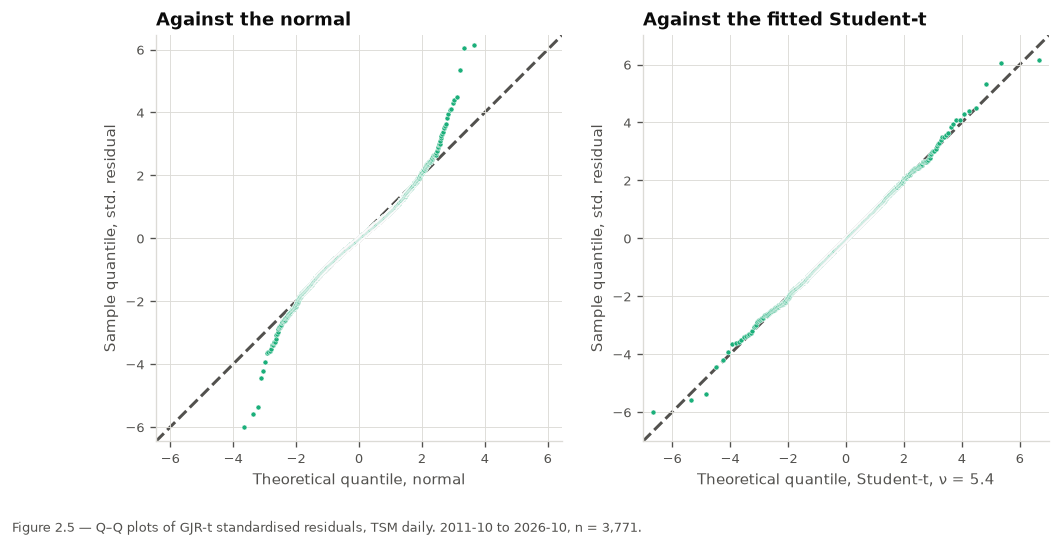

In [18]:
def residual_qq(frequency, number, appendix=False):
    z = residuals[frequency]
    nu = fits[frequency][sf.PREFERRED_MODEL].params["nu"]
    unit_t = stats.t(df=nu, scale=np.sqrt((nu - 2) / nu))  # unit-variance Student-t
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4))
    viz.qq_plot(z, axes[0], TICKER, label="Std. residual")
    viz.qq_plot(z, axes[1], TICKER, label="Std. residual", dist=unit_t, dist_label=f"Student-t, ν = {nu:.1f}")
    axes[0].set_title("Against the normal")
    axes[1].set_title("Against the fitted Student-t")
    viz.caption(
        axes[0],
        f"Figure {number} — Q–Q plots of {sf.PREFERRED_MODEL} standardised residuals, {TICKER} {frequency}"
        f"{' (appendix)' if appendix else ''}. {period(frequency)}, n = {len(z):,}.",
    )
    plt.show()

residual_qq("daily", "2.5")

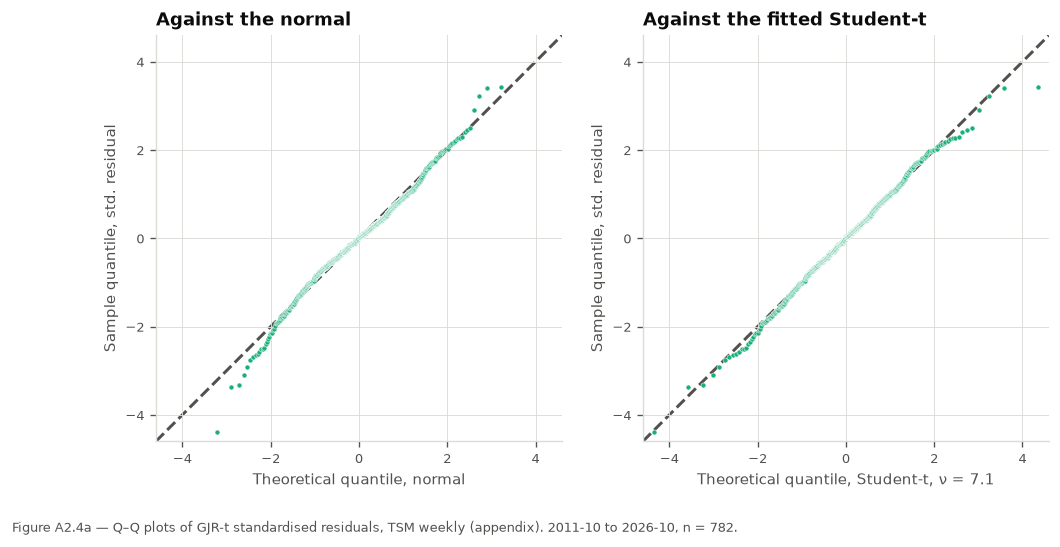

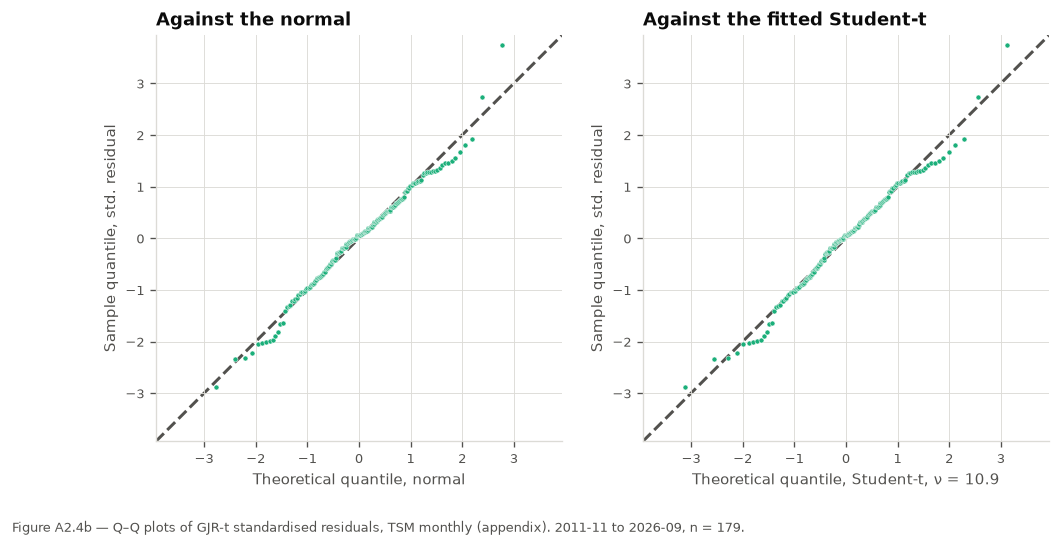

In [19]:
residual_qq("weekly", "A2.4a", appendix=True)
residual_qq("monthly", "A2.4b", appendix=True)

In [20]:
# Has the model absorbed the clustering? Ljung-Box on squared standardised residuals should not reject.
from statsmodels.stats.diagnostic import acorr_ljungbox

adequacy = pd.DataFrame(
    {frequency: acorr_ljungbox(z**2, lags=list(sf.LB_LAGS))["lb_pvalue"] for frequency, z in residuals.items()}
).T
adequacy.columns = [f"p({k})" for k in sf.LB_LAGS]
print(f"Model adequacy - Ljung-Box p-values on squared {sf.PREFERRED_MODEL} standardised residuals.")
display(fmt.style(adequacy, {c: fmt.pvalue for c in adequacy.columns}))

Model adequacy - Ljung-Box p-values on squared GJR-t standardised residuals.


,p(5),p(10),p(20)
daily,0.551,0.500,0.818
weekly,0.391,0.339,0.418
monthly,0.735,0.950,0.742


The adequacy check passes at every frequency: once each day is scaled by its conditional volatility,
no clustering is left in the squares. The model has done its job on the *second* moment — and the
residuals are **still** fat-tailed at daily and weekly frequency (excess kurtosis about 2.7 and 1.0, JB
rejecting decisively). Against the normal the daily Q–Q plot bends away in both tails; against the
fitted t(5.4) it sits close to the line. **Volatility clustering explains part of the unconditional fat
tails, not all of them** — the conditional distribution is itself non-normal, which is exactly fact 6,
and is why the Student-t error assumption beats the normal so clearly in Table 2.4.

At monthly frequency the residuals pass JB. That is the honest result, but read it with the degenerate
monthly model in mind: with α at zero these "residuals" are close to the standardised raw returns.

---

## B13 — Table 2.5, stylised facts summary

The verdict rules are fixed in `src/stylised.py` and printed below, so each cell is the mechanical
outcome of a stated rule rather than a judgment made after looking. All tests at the 5% level.

In [21]:
for fact, rule in sf.RULES.items():
    print(f"{fact}\n    {rule}\n")

1. Little or no serial correlation in raw returns
    Supported if the robust portmanteau does not reject at any of lags (5, 10, 20). Partial if it rejects but every |ρ_k|, k ≤ 20, is below 0.10 (detectable, economically negligible). Not supported otherwise.

2. Non-normal distribution, fat tails
    Supported if Jarque–Bera rejects and excess kurtosis is positive and significant (D'Agostino kurtosis test). Partial if only one of JB, Shapiro–Wilk, Anderson–Darling rejects, or kurtosis is not significant. Not supported if none rejects.

3. Asymmetry / negative skewness
    Supported if skewness is negative and significant (D'Agostino skew test). Partial if it is significant but positive (asymmetric, not the negative kind). Not supported if skewness is not significantly different from zero.

4. Volatility clustering
    Supported if Ljung–Box on |r| and r² and ARCH-LM all reject at every lag. Partial if some reject. Not supported if none does.

5. Leverage effect
    Supported if the asy

In [22]:
verdicts = sf.verdicts(descriptive, dependence, acfs, fits, residual_stats)
print(f"Table 2.5 - Stylised facts summary, {TICKER}. {period('daily')}; "
      f"n = {len(r['daily']):,} / {len(r['weekly']):,} / {len(r['monthly']):,}. "
      "Rules as printed above; 5% significance.")
display(verdicts)

Table 2.5 - Stylised facts summary, TSM. 2011-10 to 2026-10; n = 3,771 / 782 / 179. Rules as printed above; 5% significance.


daily                                                         weekly                                                        monthly  \
                                                         Verdict                                        Evidence        Verdict                                        Evidence        Verdict   
Stylised fact                                                                                                                                                                                    
1. Little or no serial correlation in raw returns        Partial           Q*(10) p<0.001; max |ρ| 0.09 at lag 1      Supported          Q*(10) p=0.940; max |ρ| 0.07 at lag 12      Supported   
2. Non-normal distribution, fat tails                  Supported                Excess kurtosis 4.14; JB p<0.001      Supported                Excess kurtosis 1.13; JB p<0.001      Supported   
3. Asymmetry / negative skewness                   Not supported                              Skew 0.01, p=0.788  Not supported                             Skew -0.01, p=0.878  Not supported   
4. Volatility clustering                               Supported            LB |r|(10) p<0.001; 9/9 tests reject      Supported            LB |r|(10) p<0.001; 9/9 tests reject        Partial   
5. Leverage effect                                 Not supported  GJR γ 0.010, p=0.360; EGARCH γ -0.016, p=0.124  Not supported  GJR γ 0.015, p=0.535; EGARCH γ -0.014, p=0.466        Partial   
6. Conditional non-normality                           Supported     Resid. excess kurt. 2.74; JB p<0.001; ν 5.4      Supported     Resid. excess kurt. 1.01; JB p<0.001; ν 7.1  Not supported   

                                                                                                                                   
                                                                                         Evidence                     Evidence in  
Stylised fact                                                                                                                      
1. Little or no serial correlation in raw returns          Q*(10) p=0.553; max |ρ| 0.16 at lag 20          Table 2.3, Figure 2.3a  
2. Non-normal distribution, fat tails                            Excess kurtosis 1.27; JB p=0.001      Tables 2.1–2.2, Figure 2.2  
3. Asymmetry / negative skewness                                               Skew 0.23, p=0.197           Table 2.1, Figure 2.2  
4. Volatility clustering                                     LB |r|(10) p=0.002; 4/9 tests reject  Table 2.3, Figures 2.1, 2.3b–c  
5. Leverage effect                                 GJR γ 0.039, p=0.501; EGARCH γ -0.009, p<0.001           Table 2.4, Figure 2.4  
6. Conditional non-normality                         Resid. excess kurt. 0.77; JB p=0.109; ν 10.9           Table 2.1, Figure 2.5

In [23]:
# Compact view: verdicts only, the grid the report opens with.
grid = verdicts.xs("Verdict", axis=1, level=1)
display(grid)
print(grid.stack().value_counts().to_string())

,daily,weekly,monthly
Stylised fact,,,
1. Little or no serial correlation in raw returns,Partial,Supported,Supported
"2. Non-normal distribution, fat tails",Supported,Supported,Supported
3. Asymmetry / negative skewness,Not supported,Not supported,Not supported
4. Volatility clustering,Supported,Supported,Partial
5. Leverage effect,Not supported,Not supported,Partial
6. Conditional non-normality,Supported,Supported,Not supported


Supported        9
Not supported    6
Partial          3


---

## Done-when checks

The plan's exit criteria for workstream B, asserted rather than eyeballed.

In [24]:
checks = []
grid = verdicts.xs("Verdict", axis=1, level=1)
allowed = {sf.SUPPORTED, sf.PARTIAL, sf.NOT_SUPPORTED}

# 1. A verdict in all 18 cells, from the allowed set.
checks.append(("Table 2.5 has a verdict in all 18 cells",
               grid.shape == (6, 3) and grid.isin(allowed).all().all()))

# 2. Every cell cites a statistic, and every row names a numbered table or figure.
evidence = verdicts.xs("Evidence", axis=1, level=1)
checks.append(("Every cell cites a statistic", evidence.notna().all().all() and (evidence != "").all().all()))
checks.append(("Every fact is backed by a numbered table or figure",
               verdicts[("", "Evidence in")].str.contains(r"(?:Table|Figure)s? 2\.\d").all()))

# 3. The analysis is not a rubber stamp: at least one honest 'Not supported'.
checks.append(("At least one cell says Not supported", (grid == sf.NOT_SUPPORTED).any().any()))

# 4. All three frequencies used complete periods only.
checks.append(("Weekly and monthly series are complete periods only",
               r["monthly"].index[-1] <= panel.calendar[-1] and r["weekly"].index[-1] <= panel.calendar[-1]))

# 5. Estimation problems are logged, not dropped: every model at every frequency has a result.
checks.append(("Every model fitted at every frequency, failures logged",
               all(len(f) == len(sf.MODELS) for f in fits.values())))

for label, passed in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {label}")
assert all(passed for _, passed in checks), "Workstream B exit criteria not met"
print("\nWorkstream B complete.")

[PASS] Table 2.5 has a verdict in all 18 cells
[PASS] Every cell cites a statistic
[PASS] Every fact is backed by a numbered table or figure
[PASS] At least one cell says Not supported
[PASS] Weekly and monthly series are complete periods only
[PASS] Every model fitted at every frequency, failures logged

Workstream B complete.


---

## Handoff

Report section 3 consumes Tables 2.1–2.5 and Figures 2.1–2.5; the appendix takes Tables A2.1–A2.2 and
Figures A2.1–A2.4. Nothing here feeds the backtest — the portfolio strategies use simple returns from
`data.build_returns` directly.

Two findings the later sections should carry forward:

| Finding | Where it matters |
| --- | --- |
| Strong, persistent daily volatility clustering (persistence ≈ 0.99) | Section 4: a trailing one-year covariance estimate lags volatility regimes; part of why the walk-forward refit matters |
| Conditional fat tails (t, ν ≈ 5) | Section 6: volatility and Sharpe-based comparisons understate tail risk; drawdown metrics are the necessary complement |